In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# ------------------------------------------------------------------
# CONFIGURACIÓN: editá estas tres variables según lo que necesites
# ------------------------------------------------------------------
ARCHIVO = "UTILITY.xls"          # nombre (o ruta) del archivo Excel
COLUMNA = "Utility Charge"              # nombre de la columna a analizar
CANTIDAD_INTERVALOS = 5         # cantidad de intervalos
# ------------------------------------------------------------------


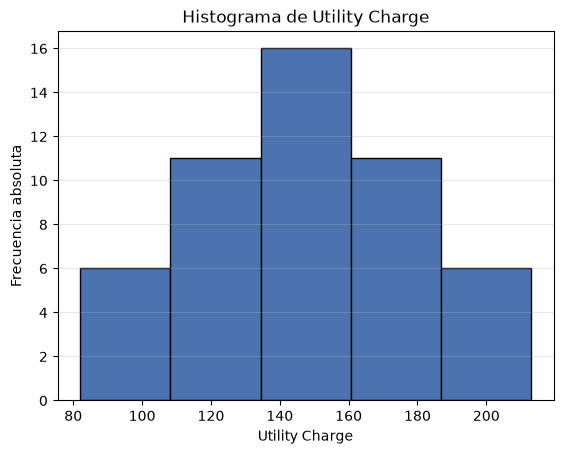

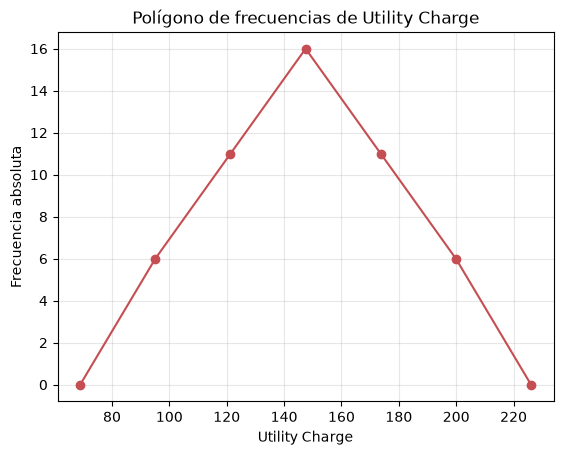

In [ ]:
def cargar_datos(archivo: str, columna: str) -> pd.Series:
    ruta = archivo if os.path.isabs(archivo) else os.path.join(os.getcwd(), archivo)

    if not os.path.exists(ruta):
        raise FileNotFoundError(f"No se encontró el archivo: {ruta}")

    df = pd.read_excel(ruta)

    if columna not in df.columns:
        raise ValueError(
            f"La columna '{columna}' no existe en el archivo. "
            f"Columnas disponibles: {list(df.columns)}"
        )

    datos = pd.to_numeric(df[columna], errors="coerce").dropna()

    if datos.empty:
        raise ValueError(f"La columna '{columna}' no tiene datos numéricos.")

    return datos


def graficar_histograma(datos: pd.Series, columna: str, cantidad_intervalos: int):
    plt.figure()
    conteo, bordes, _ = plt.hist(
        datos, bins=cantidad_intervalos, edgecolor="black", color="#4C72B0"
    )

    plt.title(f"Histograma de {columna}")
    plt.xlabel(columna)
    plt.ylabel("Frecuencia absoluta")
    plt.grid(axis="y", alpha=0.3)
    plt.show()

    return conteo, bordes


def graficar_poligono_frecuencia(conteo, bordes, columna: str):
    marcas_de_clase = (bordes[:-1] + bordes[1:]) / 2
    amplitud = bordes[1] - bordes[0]

    # Se agrega un punto en 0 antes de la primera clase y otro después de la
    # última, para "cerrar" el polígono sobre el eje x (una amplitud de clase
    # más allá de cada extremo).
    x_poligono = [marcas_de_clase[0] - amplitud] + list(marcas_de_clase) + [marcas_de_clase[-1] + amplitud]
    y_poligono = [0] + list(conteo) + [0]

    plt.figure()
    plt.plot(x_poligono, y_poligono, marker="o", color="#C44E52")
    plt.title(f"Polígono de frecuencias de {columna}")
    plt.xlabel(columna)
    plt.ylabel("Frecuencia absoluta")
    plt.grid(alpha=0.3)
    plt.show()


def main():
    datos = cargar_datos(ARCHIVO, COLUMNA)
    conteo, bordes = graficar_histograma(datos, COLUMNA, CANTIDAD_INTERVALOS)
    graficar_poligono_frecuencia(conteo, bordes, COLUMNA)


if __name__ == "__main__":
    main()